In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

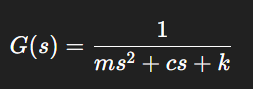

In [10]:
m = 1.0
c = 2.0
k = 5.0

sys = ct.TransferFunction([1], [m, c, k])

t, y = ct.step_response(sys)

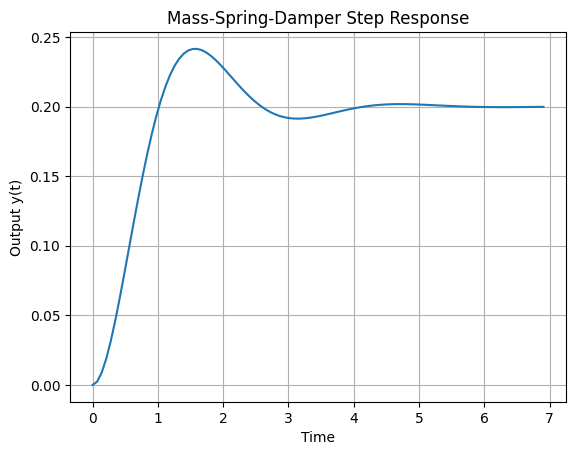

In [11]:
plt.plot(t, y)
plt.xlabel('Time')
plt.ylabel('Output y(t)')
plt.title('Mass-Spring-Damper Step Response')
plt.grid(True)
plt.show()

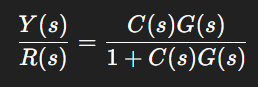

In [12]:
# =========================
# 1. Second-order plant
# G(s) = 1 / (m s^2 + c s + k)
# =========================
m = 1.0
c = 2.0
k = 5.0
G = ct.TransferFunction([1], [m, c, k])

In [53]:
# =========================
# 2. PID controller
# C(s) = Kp + Ki/s + Kd*s
#      = (Kd*s^2 + Kp*s + Ki) / s
# =========================
Kp = 10.0
Ki = 10.0
Kd = 1.0
C = ct.TransferFunction([Kd, Kp, Ki], [1, 0])

In [54]:
# =========================
# 3. Closed-loop system
# =========================
closed_sys = ct.feedback(C * G, 1)

# =========================
# 4. Step response
# =========================
t, y = ct.step_response(closed_sys)

In [55]:
# 지표 추출
info = ct.step_info(closed_sys)

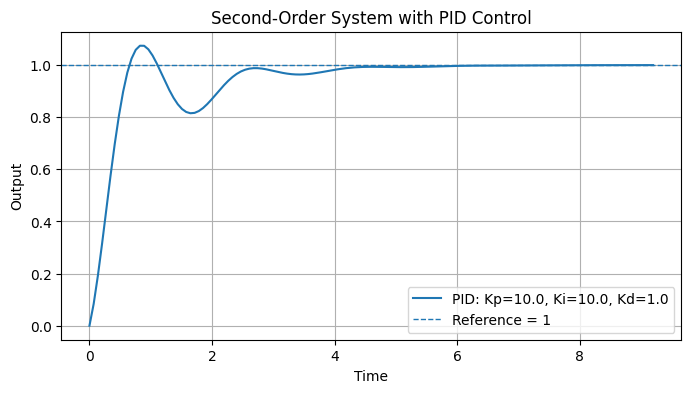

In [56]:
plt.figure(figsize=(8, 4))
plt.plot(t, y, label=f'PID: Kp={Kp}, Ki={Ki}, Kd={Kd}')
plt.axhline(1.0, linestyle='--', linewidth=1, label='Reference = 1')
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Second-Order System with PID Control')
plt.grid(True)
plt.legend()
plt.show()

In [57]:
info

{'RiseTime': 0.48031606582989916,
 'SettlingTime': 3.9797616883048788,
 'SettlingMin': 0.8150160474443892,
 'SettlingMax': 1.0740165806237556,
 'Overshoot': 7.40165806237556,
 'Undershoot': 0,
 'Peak': 1.0740165806237556,
 'PeakTime': 0.8233989699941129,
 'SteadyStateValue': 1.0}

Final value      : 0.9996
Peak value       : 0.9996
Peak time        : 18.8869 s
Overshoot        : 0.00 %
Settling time(2%): 7.8129 s


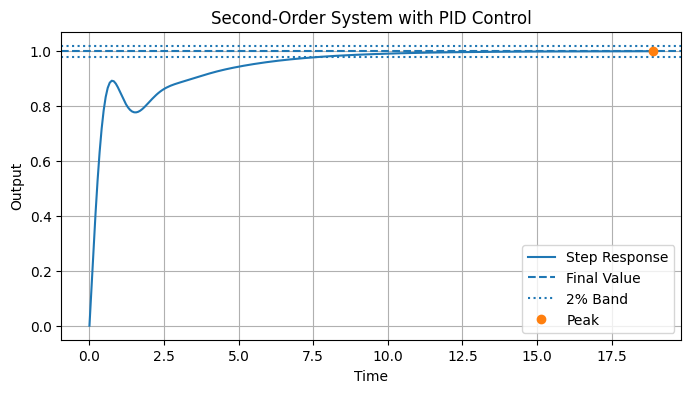

In [58]:
# =========================
# 1. Second-order plant
# =========================
m = 1.0
c = 2.0
k = 5.0
G = ct.TransferFunction([1], [m, c, k])

# =========================
# 2. PID controller
# =========================
Kp = 10.0
Ki = 5.0
Kd = 2.0
C = ct.TransferFunction([Kd, Kp, Ki], [1, 0])

# =========================
# 3. Closed-loop system
# =========================
closed_sys = ct.feedback(C * G, 1)

# =========================
# 4. Step response
# =========================
T, y = ct.step_response(closed_sys)

# =========================
# 5. Metrics calculation
# =========================
y_final = y[-1]

# Peak value / Peak time
peak_idx = np.argmax(y)
peak_value = y[peak_idx]
peak_time = T[peak_idx]

# Overshoot (%)
overshoot = max(0, (peak_value - y_final) / y_final * 100)

# Settling time (2% band)
tol = 0.02
lower = y_final * (1 - tol)
upper = y_final * (1 + tol)

settling_time = None
for i in range(len(y)):
    if np.all((y[i:] >= lower) & (y[i:] <= upper)):
        settling_time = T[i]
        break

print(f"Final value      : {y_final:.4f}")
print(f"Peak value       : {peak_value:.4f}")
print(f"Peak time        : {peak_time:.4f} s")
print(f"Overshoot        : {overshoot:.2f} %")
print(f"Settling time(2%): {settling_time:.4f} s")

# =========================
# 6. Plot
# =========================
plt.figure(figsize=(8, 4))
plt.plot(T, y, label='Step Response')
plt.axhline(y_final, linestyle='--', label='Final Value')
plt.axhline(lower, linestyle=':', label='2% Band')
plt.axhline(upper, linestyle=':')
plt.plot(peak_time, peak_value, 'o', label='Peak')
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Second-Order System with PID Control')
plt.grid(True)
plt.legend()
plt.show()